In [38]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import kagglehub
from imblearn.over_sampling import SMOTE
from rich.jupyter import display


In [31]:
#Download latest version
path = kagglehub.dataset_download("algozee/teenager-menthal-healy")
kagglehub.login()

print("Path to dataset files:", path)

Path to dataset files: /Users/danniells/.cache/kagglehub/datasets/algozee/teenager-menthal-healy/versions/1


In [2]:
print("Arquivos no dataset:", os.listdir(path)) #verifica quais arquivos estão dentro da pasta

Arquivos no dataset: ['Teen_Mental_Health_Dataset.csv']


In [3]:
rota = os.path.join('/Users/danniells/.cache/kagglehub/datasets/algozee/teenager-menthal-healy/versions/1', 'Teen_Mental_Health_Dataset.csv') #junta o caminho da pasta com o arquivo

In [12]:
df = pd.read_csv(rota)
df.shape #linhas + colunas

(1200, 13)

# Visão Geral do Dataset

Esse Dataset estuda como o uso de redes sociais afeta a saúde mental de adolescentes. Ele inclui hábitos diários como tempo gasto em redes sociais, sono, estresse, ansiedade e atividade física.

O objetivo é entender se o uso elevado de redes sociais está relacionado a problemas como estresse, ansiedade e depressão. Os dados ajudam na análise de comportamento e na construção de modelos de machine learning para prever riscos à saúde mental.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


- Qual é a força da correlação entre `daily_social_media_hours` e os 4 níveis de impacto (`stress_level`, `anxiety_level`, `addiction_level` e `depression_label`)?
- Como o screen_time_before_sleep atua como um multiplicador negativo na qualidade do sono (`sleep_hours`) e como isso reflete no dia seguinte?
- Adolescentes com maior taxa de `physical_activity` apresentam níveis significativamente menores de estresse ou ansiedade, mesmo mantendo alto uso de redes sociais?
- A plataforma utilizada (`platform_usage`, como TikTok vs Instagram) isola comportamentos específicos? O impacto no `academic_performance` muda de acordo com a rede escolhida?

In [55]:
#Primeira Pergunta

cols = ['daily_social_media_hours', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']
new_df = df[cols]

#vai calcular a matriz de correlação
matrix = new_df.corr()

print("Matriz de Correlação:")
print(matrix.to_markdown())

Matriz de Correlação:
|                          |   daily_social_media_hours |   stress_level |   anxiety_level |   addiction_level |   depression_label |
|:-------------------------|---------------------------:|---------------:|----------------:|------------------:|-------------------:|
| daily_social_media_hours |                  1         |    0.0306977   |       0.0278348 |      -0.0249641   |          0.175201  |
| stress_level             |                  0.0306977 |    1           |       0.0158113 |      -0.000129395 |          0.170474  |
| anxiety_level            |                  0.0278348 |    0.0158113   |       1         |       0.0311538   |          0.169566  |
| addiction_level          |                 -0.0249641 |   -0.000129395 |       0.0311538 |       1           |         -0.0139521 |
| depression_label         |                  0.175201  |    0.170474    |       0.169566  |      -0.0139521   |          1         |


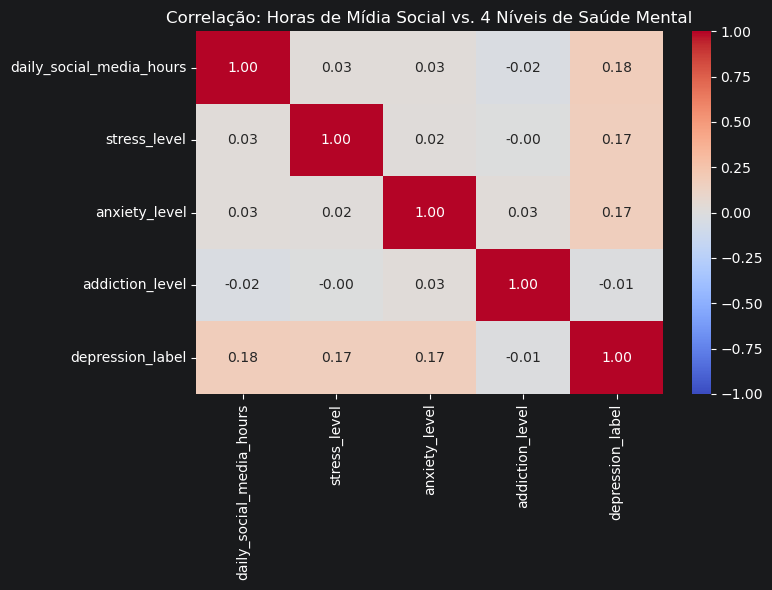

In [58]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix,
    annot=True,          # Mostra os valores numéricos em cada célula
    cmap='coolwarm',     # Esquema de cores: azul para negativo, vermelho para positivo
    vmin=-1, vmax=1,     # Fixa a escala de -1 a 1 para precisão visual
    fmt=".2f"           # Formata as casas decimais
)
plt.title('Correlação: Horas de Mídia Social vs. 4 Níveis de Saúde Mental')
plt.tight_layout()
plt.show()

Apesar da correlação ser fraca, verificamos que `depression_label` é a única que teve uma correlação maior com as demais colunas